1. Import Libraries
# Task 2 — Quantitative Financial Analysis

## Predicting Price Moves with News Sentiment

This notebook performs quantitative analysis on historical stock market data using technical indicators and financial metrics.

Objectives:
- Load and clean historical stock price data
- Compute technical indicators using the `ta` library
- Analyze stock momentum and volatility
- Compare performance across multiple technology stocks
- Build a reusable stock analysis workflow
- Generate visual insights for trend and momentum analysis
- Prepare data for future sentiment-return correlation analysis

Stocks Analyzed:
- AAPL
- AMZN
- GOOG
- META
- NVDA

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from ta.trend import SMAIndicator, EMAIndicator, MACD
from ta.momentum import RSIIndicator

import warnings
warnings.filterwarnings('ignore')

2. Create Data Paths

In [6]:
RAW_DATA_PATH = "../data/Data"
PROCESSED_DATA_PATH = "../data/processed"

3. Load All CSV Files Automatically

In [7]:
from glob import glob

csv_files = glob(f"{RAW_DATA_PATH}/*.csv")

csv_files

['../data/Data\\AAPL.csv',
 '../data/Data\\AMZN.csv',
 '../data/Data\\GOOG.csv',
 '../data/Data\\META.csv',
 '../data/Data\\NVDA.csv']

4. Build Reusable Analysis Function

In [ ]:
def analyze_stock(filepath):
    """
    Load and analyze historical stock price data.

    This function:
    - loads stock CSV data
    - cleans and prepares the dataset
    - computes technical indicators
    - calculates daily returns

    Technical indicators computed:
    - SMA (Simple Moving Average)
    - EMA (Exponential Moving Average)
    - RSI (Relative Strength Index)
    - MACD (Moving Average Convergence Divergence)

    These indicators will later be used in Task 3
    to analyze relationships between market sentiment
    and stock price movements.
    """

    # Extract stock ticker name from filename
    stock_name = Path(filepath).stem

    print(f"\nAnalyzing {stock_name}...")

    # Load CSV
    df = pd.read_csv(filepath)

    print("Columns:", df.columns.tolist())

    # =========================
    # Data Preparation
    # =========================

    # Convert Date column to datetime
    df['Date'] = pd.to_datetime(df['Date'])

    # Sort chronologically
    df.sort_values('Date', inplace=True)

    # Set Date as index
    df.set_index('Date', inplace=True)

    # Define numeric columns
    numeric_cols = ['Open', 'High', 'Low', 'Close', 'Volume']

    # Convert columns to numeric format
    df[numeric_cols] = df[numeric_cols].apply(
        pd.to_numeric,
        errors='coerce'
    )

    # Remove missing values
    df.dropna(inplace=True)

    # =========================
    # Technical Indicators
    # =========================

    # 20-Day Simple Moving Average (SMA)
    # SMA helps identify overall market trend direction
    df['SMA_20'] = SMAIndicator(
        close=df['Close'],
        window=20
    ).sma_indicator()

    # 20-Day Exponential Moving Average (EMA)
    # EMA reacts faster to recent price changes
    df['EMA_20'] = EMAIndicator(
        close=df['Close'],
        window=20
    ).ema_indicator()

    # Relative Strength Index (RSI)
    # RSI > 70 indicates overbought conditions
    # RSI < 30 indicates oversold conditions
    df['RSI'] = RSIIndicator(
        close=df['Close'],
        window=14
    ).rsi()

    # MACD measures momentum and trend reversals
    macd = MACD(close=df['Close'])

    df['MACD'] = macd.macd()
    df['MACD_Signal'] = macd.macd_signal()

    # =========================
    # Return Calculation
    # =========================

    # Daily percentage return
    df['Daily_Return'] = df['Close'].pct_change()

    # Remove rows with NaN values generated by indicators
    df.dropna(inplace=True)

    return df

5. Run Workflow for All Stocks

In [14]:
# Get all CSV files
csv_files = glob(f"{RAW_DATA_PATH}/*.csv")

all_data = {}

for file in csv_files:

    stock_name = Path(file).stem

    analyzed_df = analyze_stock(file)

    all_data[stock_name] = analyzed_df


Analyzing AAPL...
Columns: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']

Analyzing AMZN...
Columns: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']

Analyzing GOOG...
Columns: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']

Analyzing META...
Columns: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']

Analyzing NVDA...
Columns: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']


In [15]:
all_data['AAPL'].head()

,Close,High,Low,Open,Volume,SMA_20,EMA_20,RSI,MACD,MACD_Signal,Daily_Return
Date,,,,,,,,,,,
2009-01-02,2.721686,2.730385,2.554037,2.575630,7.460152e+08,NaN,NaN,NaN,NaN,NaN,NaN
2009-01-05,2.836553,2.884539,2.780469,2.794266,1.181608e+09,NaN,NaN,NaN,NaN,NaN,0.042204
2009-01-06,2.789767,2.914229,2.770872,2.877641,1.289310e+09,NaN,NaN,NaN,NaN,NaN,-0.016494
2009-01-07,2.729484,2.774170,2.706990,2.753477,7.530488e+08,NaN,NaN,NaN,NaN,NaN,-0.021609
2009-01-08,2.780169,2.793666,2.700393,2.712090,6.735008e+08,NaN,NaN,NaN,NaN,NaN,0.018570


6. Visualize Any Stock

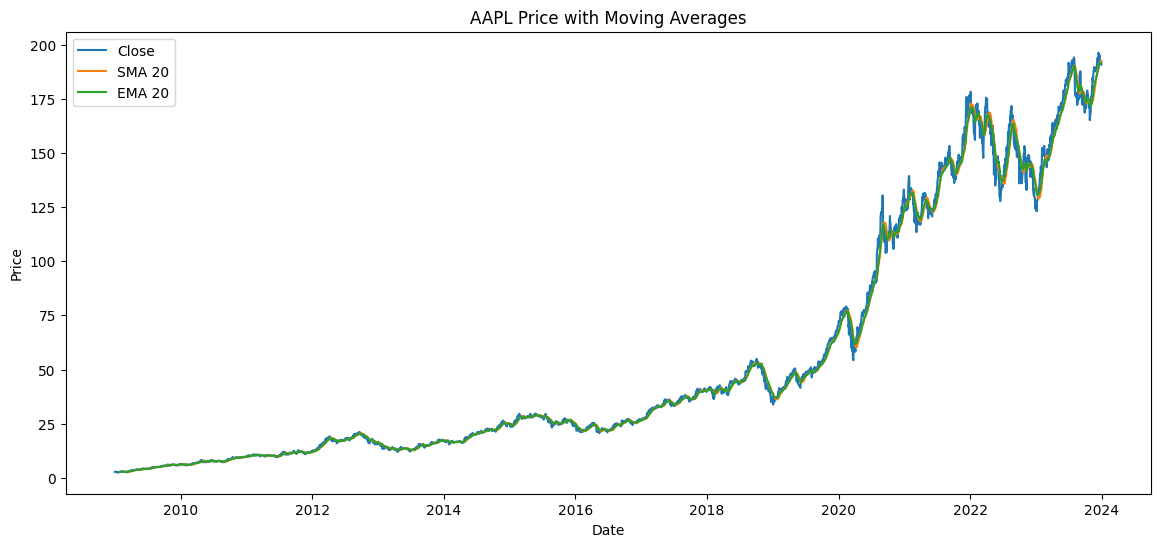

In [19]:
#Example for AAPL
aapl_df = all_data['AAPL']

plt.figure(figsize=(14,6))

plt.plot(aapl_df.index, aapl_df['Close'], label='Close')
plt.plot(aapl_df.index, aapl_df['SMA_20'], label='SMA 20')
plt.plot(aapl_df.index, aapl_df['EMA_20'], label='EMA 20')

plt.title('AAPL Price with Moving Averages')

plt.xlabel('Date')
plt.ylabel('Price')

plt.legend()

plt.show()

7. Create Reusable Visualization Function

In [20]:
def plot_stock_indicators(df, stock_name):
    
    # Price Plot
    plt.figure(figsize=(14,6))
    
    plt.plot(df.index, df['Close'], label='Close')
    plt.plot(df.index, df['SMA_20'], label='SMA 20')
    plt.plot(df.index, df['EMA_20'], label='EMA 20')
    
    plt.title(f'{stock_name} Price with Moving Averages')
    
    plt.legend()
    
    plt.show()
    
    # RSI Plot
    plt.figure(figsize=(14,4))
    
    plt.plot(df.index, df['RSI'], label='RSI')
    
    plt.axhline(70, linestyle='--')
    plt.axhline(30, linestyle='--')
    
    plt.title(f'{stock_name} RSI')
    
    plt.legend()
    
    plt.show()
    
    # MACD Plot
    plt.figure(figsize=(14,4))
    
    plt.plot(df.index, df['MACD'], label='MACD')
    plt.plot(df.index, df['MACD_Signal'], label='Signal')
    
    plt.title(f'{stock_name} MACD')
    
    plt.legend()
    
    plt.show()

8. Use Visualization Function

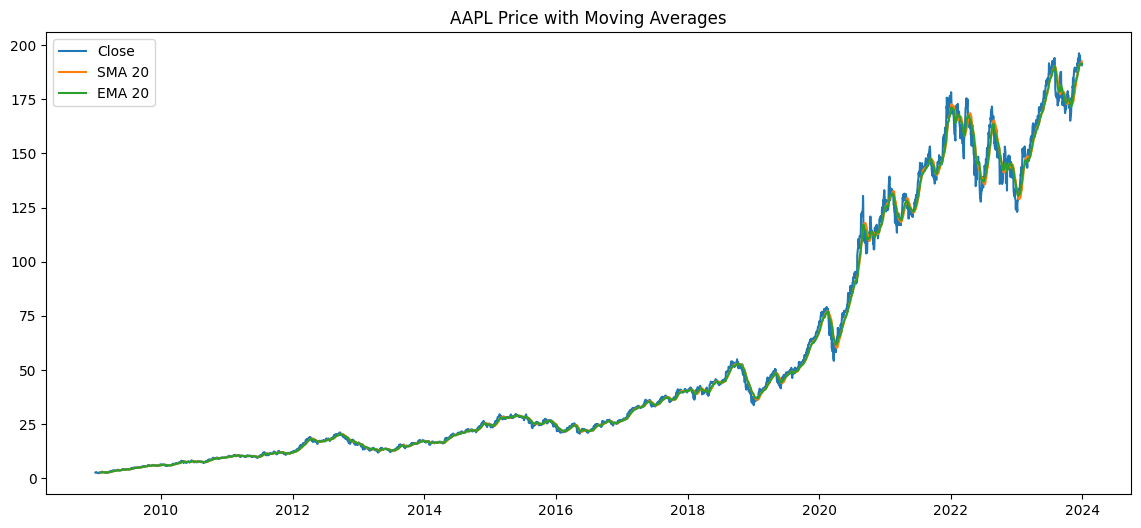

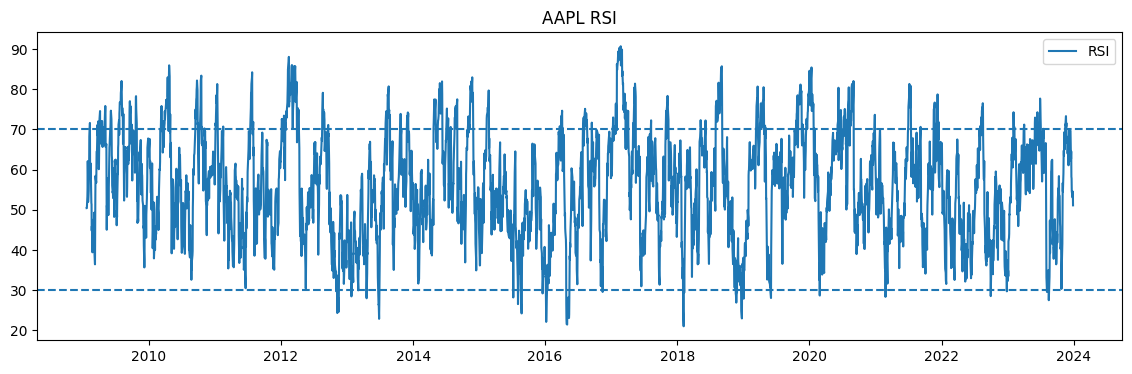

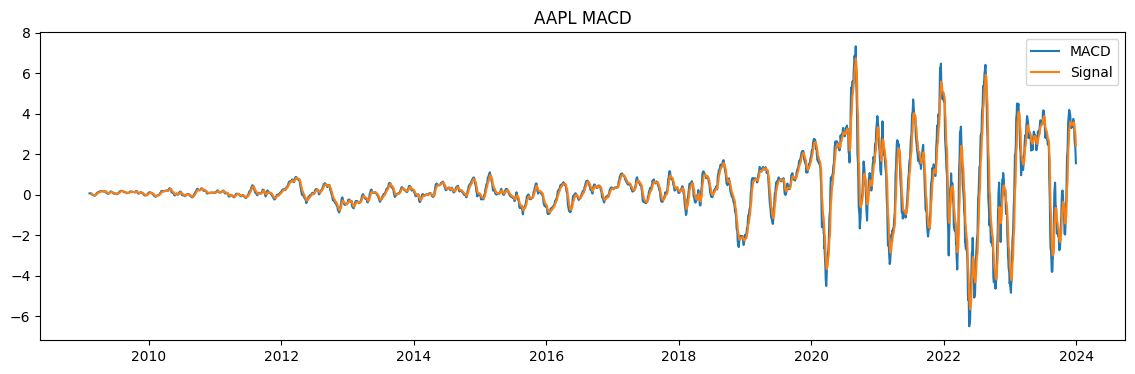

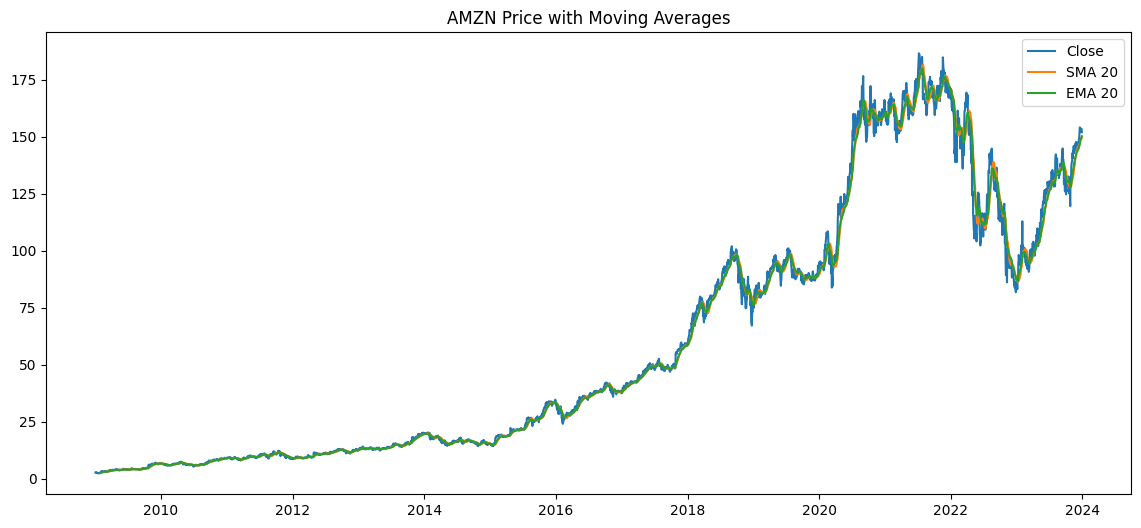

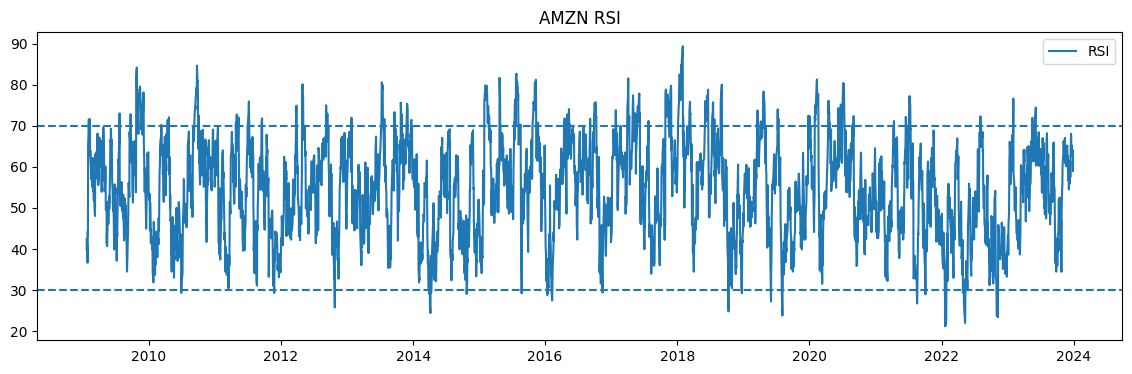

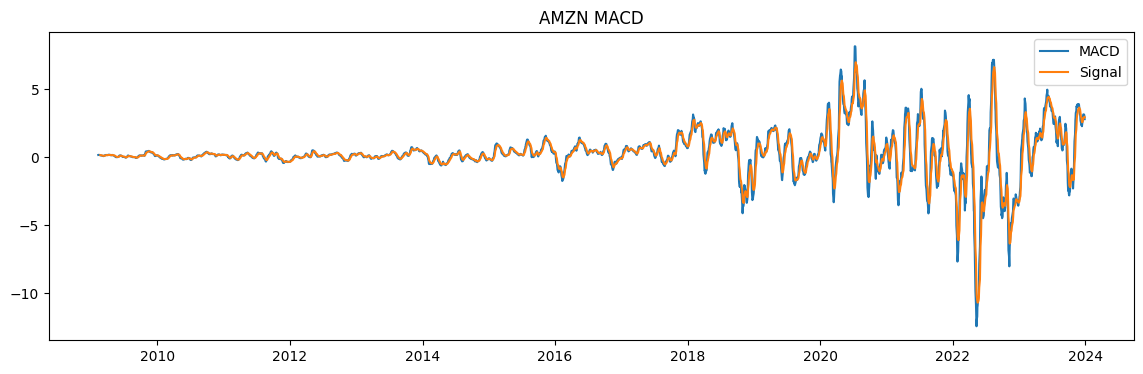

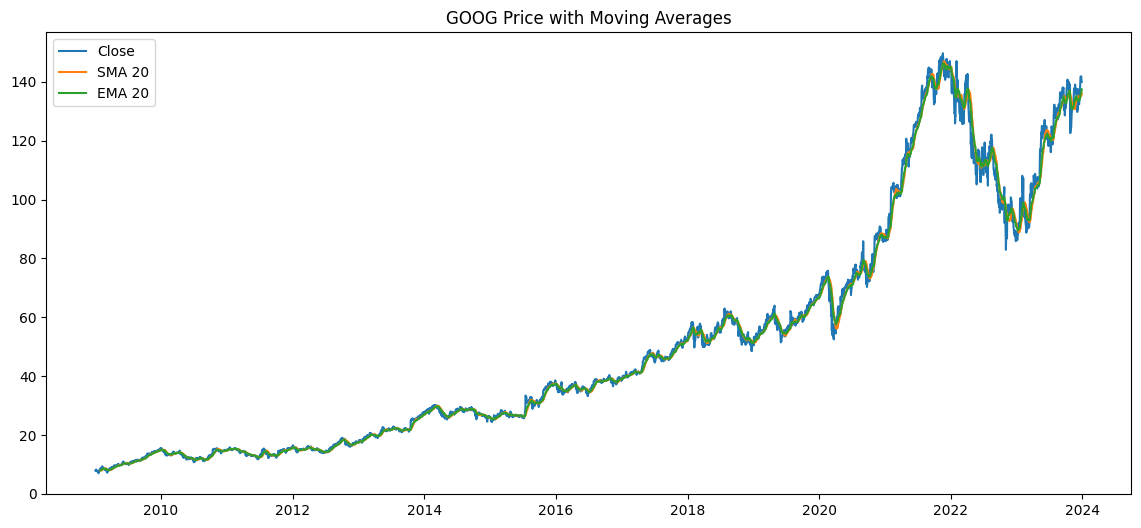

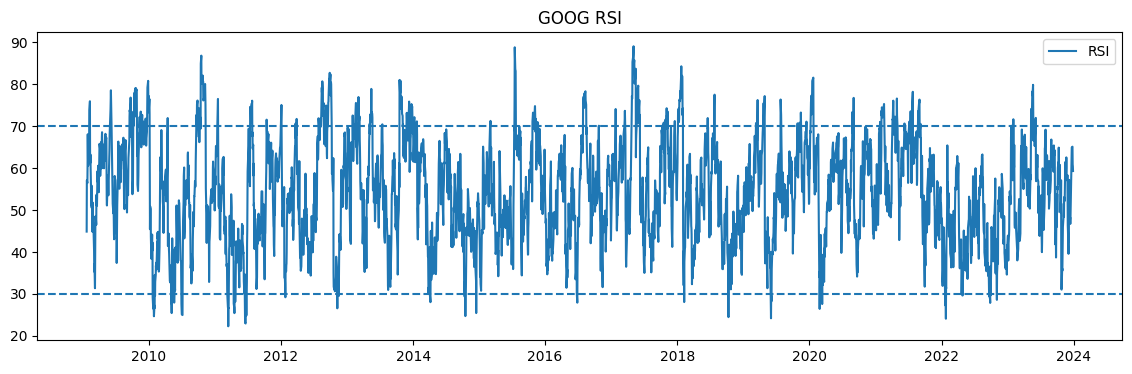

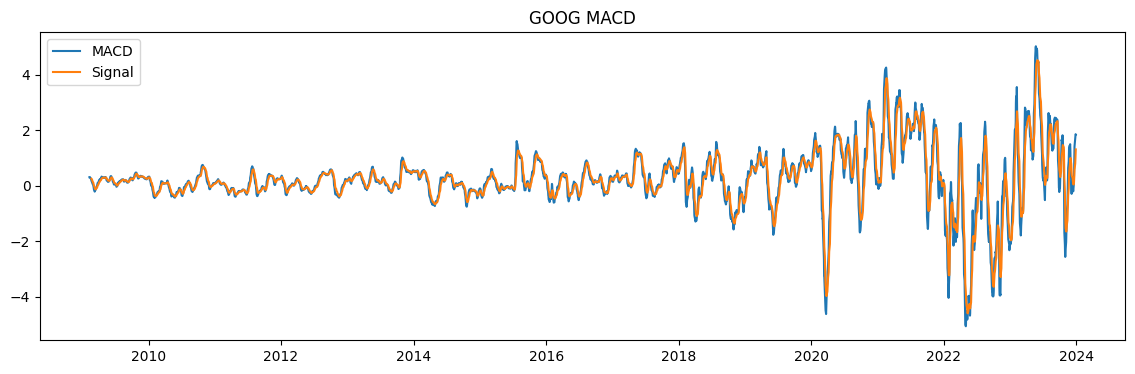

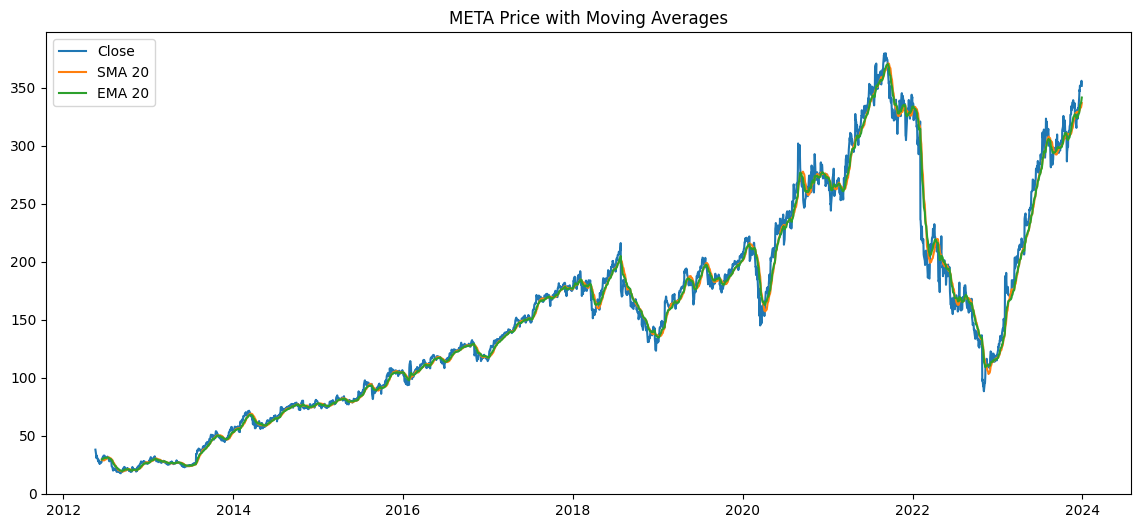

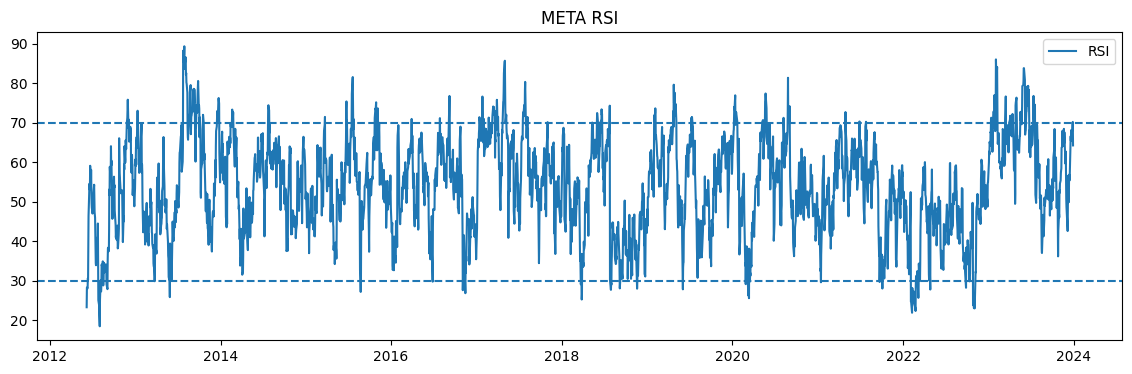

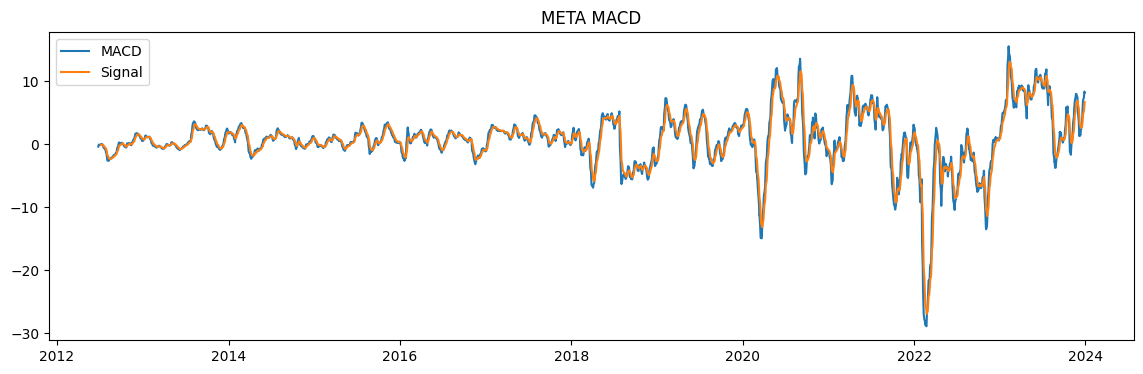

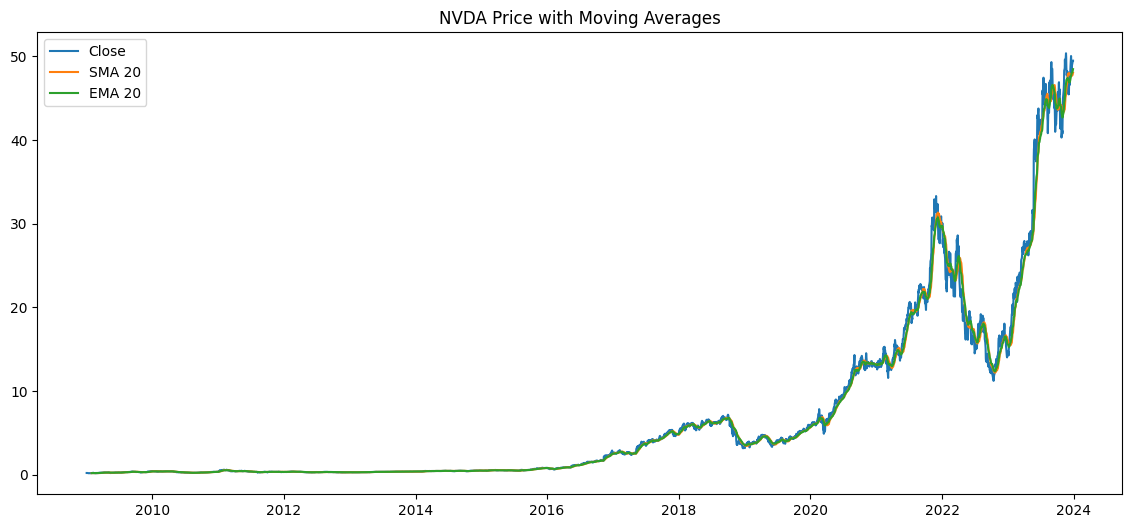

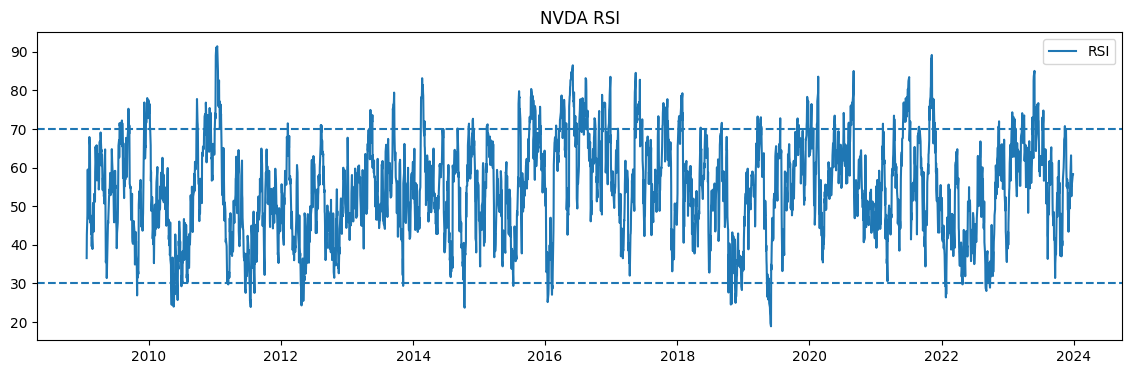

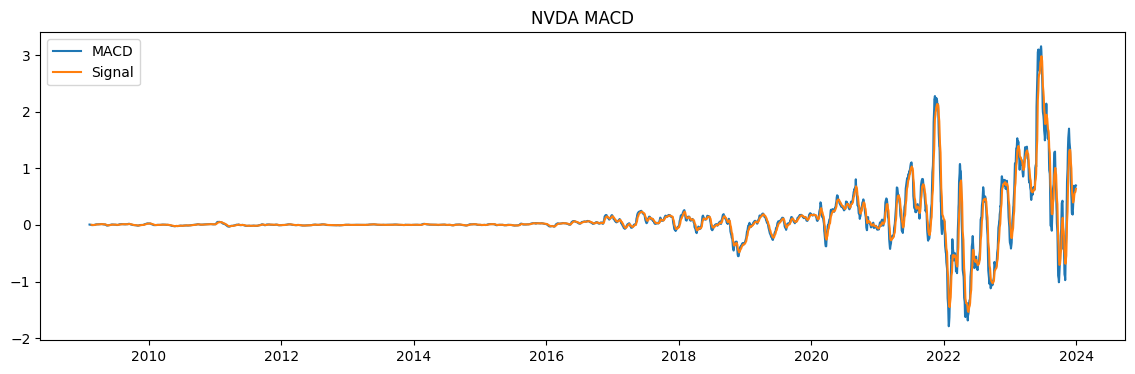

In [21]:
for stock_name, stock_df in all_data.items():
    
    plot_stock_indicators(stock_df, stock_name)

9. Create Summary Table

In [22]:
summary = []

for stock_name, df in all_data.items():
    
    summary.append({
        'Stock': stock_name,
        'Latest Close': df['Close'].iloc[-1],
        'Average Return': df['Daily_Return'].mean(),
        'Volatility': df['Daily_Return'].std(),
        'Latest RSI': df['RSI'].iloc[-1]
    })

summary_df = pd.DataFrame(summary)

summary_df

,Stock,Latest Close,Average Return,Volatility,Latest RSI
0,AAPL,190.728775,0.001289,0.018010,51.121347
1,AMZN,151.940002,0.001303,0.021829,59.012257
2,GOOG,139.972137,0.000910,0.017334,59.313063
3,META,351.791290,0.001082,0.025280,64.296803
4,NVDA,49.497185,0.001877,0.028917,58.310919
